# Task 4 — Visualization and Results Presentation

Create comprehensive visualizations of integrative genomics analysis using **real TCGA-BRCA data** (277 breast cancer samples).

**Visualizations:**
- PCA scatter plots colored by molecular subtype (Basal vs Others)
- Clustering dendrograms (hierarchical)
- Volcano plots for differential expression
- Feature importance plots from Random Forest
- Model comparison charts

## 1. Initialize Project Environment

In [ ]:
"""Setup and imports for visualization."""
import logging
import sys
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 10

print(f"Python {sys.version}")
print(f"matplotlib {plt.matplotlib.__version__}")

Python 3.12.3 (main, Jan  8 2026, 11:30:50) [GCC 13.3.0]
matplotlib 3.9.4


## 2. Define Configuration Parameters

In [ ]:
@dataclass
class Task4Config:
    """Configuration for visualization."""

    handle: str = "AndreiCod"
    export_dir: Path = Path("./artifacts")
    data_dir: Path = Path("./artifacts")
    random_seed: int = 42
    figure_format: str = "png"

    def __post_init__(self):
        self.export_dir.mkdir(parents=True, exist_ok=True)

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["export_dir"] = str(info["export_dir"])
        info["data_dir"] = str(info["data_dir"])
        return info


CONFIG = Task4Config()
CONFIG.describe()

{'handle': 'AndreiCod',
 'export_dir': 'artifacts',
 'data_dir': 'artifacts',
 'random_seed': 42,
 'figure_format': 'png'}

## 3. Load All TCGA-BRCA Results

In [ ]:
# Load TCGA-BRCA data from previous tasks
X_integrated = pd.read_csv(
    CONFIG.data_dir / "task2_integrated_features.csv", index_col=0
)
X_pca = pd.read_csv(CONFIG.data_dir / "task2_pca_features.csv", index_col=0)
pheno_df = pd.read_csv(CONFIG.data_dir / "task1_phenotypes.csv", index_col=0)

# Load experiment results
threshold_results = pd.read_csv(CONFIG.data_dir / "task2_threshold_experiment.csv")
clustering_results = pd.read_csv(CONFIG.data_dir / "task2_clustering_comparison.csv")
ml_results = pd.read_csv(CONFIG.data_dir / "task2_ml_comparison.csv")

# Load biological interpretation results
de_results = pd.read_csv(CONFIG.data_dir / "task3_differential_expression.csv")
rf_importance = pd.read_csv(CONFIG.data_dir / "task3_feature_importance.csv")

# Prepare phenotype
y = pheno_df["phenotype"].map({"responder": 1, "non_responder": 0})

print(f"{'=' * 60}")
print("LOADED TCGA-BRCA VISUALIZATION DATA")
print(f"{'=' * 60}")
print(f"PCA features: {X_pca.shape}")
print(f"Samples: {len(y)}")
print(f"Molecular subtypes: {pheno_df['molecular_subtype'].nunique()}")

LOADED TCGA-BRCA VISUALIZATION DATA
PCA features: (277, 10)
Samples: 277
Molecular subtypes: 5


## 4. PCA Visualization

[OK] Saved: artifacts/task4_pca_phenotype.png


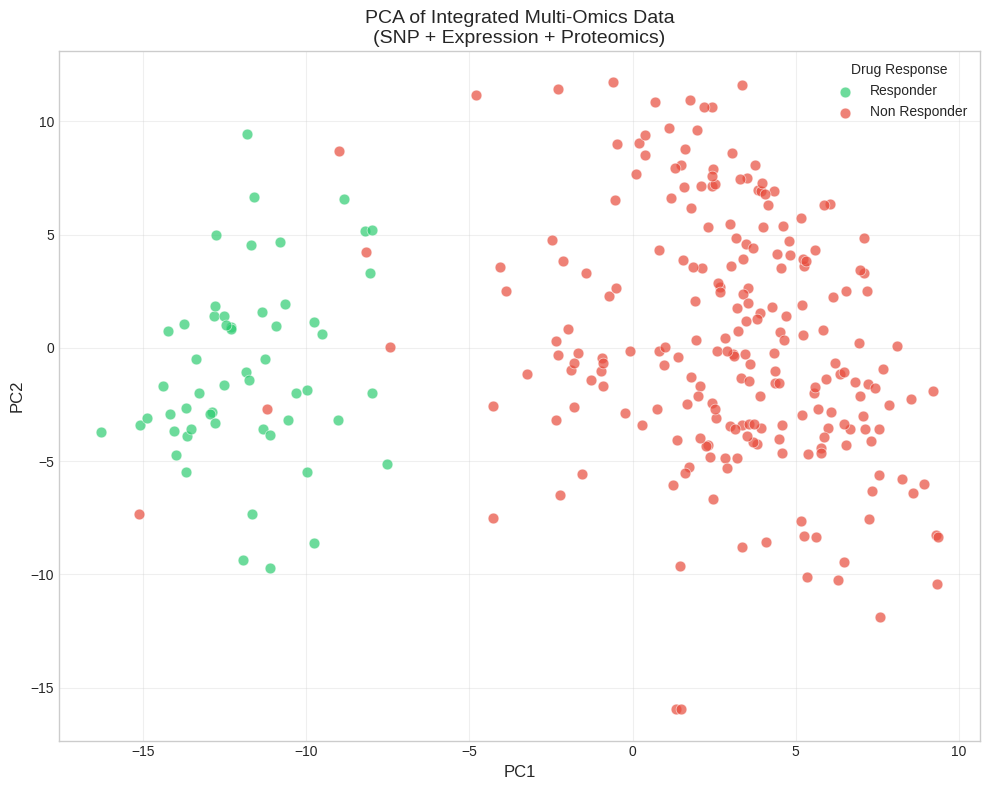

In [ ]:
def plot_pca_by_phenotype(
    X_pca: pd.DataFrame, pheno: pd.Series, save_path: Path = None
):
    """Create PCA scatter plot colored by phenotype."""

    fig, ax = plt.subplots(figsize=(10, 8))

    colors = {"responder": "#2ecc71", "non_responder": "#e74c3c"}

    for phenotype in ["responder", "non_responder"]:
        mask = pheno == phenotype
        samples = pheno[mask].index

        ax.scatter(
            X_pca.loc[samples, "PC1"],
            X_pca.loc[samples, "PC2"],
            c=colors[phenotype],
            label=phenotype.replace("_", " ").title(),
            alpha=0.7,
            s=60,
            edgecolor="white",
            linewidth=0.5,
        )

    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_title(
        "PCA of Integrated Multi-Omics Data\n(SNP + Expression + Proteomics)",
        fontsize=14,
    )
    ax.legend(title="Drug Response", loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_pca_by_phenotype(
    X_pca,
    pheno_df["phenotype"],
    CONFIG.export_dir / f"task4_pca_phenotype.{CONFIG.figure_format}",
)

[OK] Saved: artifacts/task4_pca_clusters.png


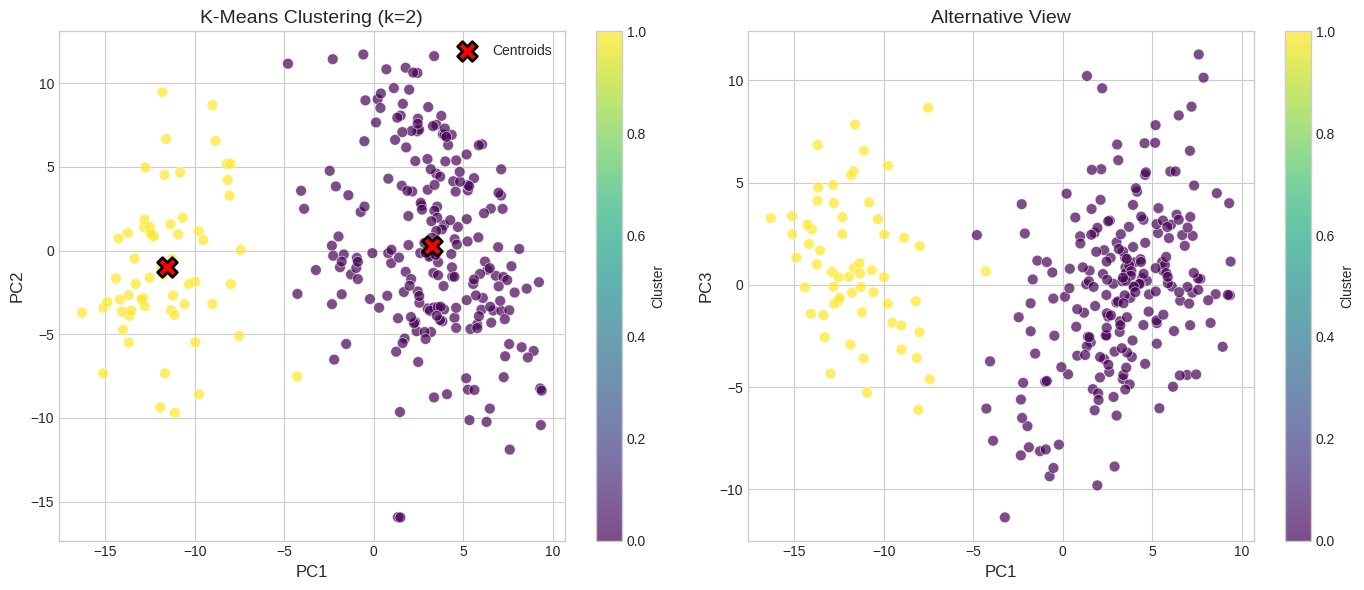

In [ ]:
def plot_pca_with_clusters(
    X_pca: pd.DataFrame, n_clusters: int = 2, seed: int = 42, save_path: Path = None
):
    """Create PCA plot colored by K-means clusters."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    clusters = kmeans.fit_predict(X_pca.values)

    # Plot 1: Clusters
    scatter = axes[0].scatter(
        X_pca["PC1"],
        X_pca["PC2"],
        c=clusters,
        cmap="viridis",
        alpha=0.7,
        s=60,
        edgecolor="white",
        linewidth=0.5,
    )
    axes[0].scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        c="red",
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=2,
        label="Centroids",
    )
    axes[0].set_xlabel("PC1", fontsize=12)
    axes[0].set_ylabel("PC2", fontsize=12)
    axes[0].set_title("K-Means Clustering (k=2)", fontsize=14)
    axes[0].legend()
    plt.colorbar(scatter, ax=axes[0], label="Cluster")

    # Plot 2: PC1 vs PC3
    scatter2 = axes[1].scatter(
        X_pca["PC1"],
        X_pca["PC3"] if "PC3" in X_pca.columns else X_pca["PC2"],
        c=clusters,
        cmap="viridis",
        alpha=0.7,
        s=60,
        edgecolor="white",
        linewidth=0.5,
    )
    axes[1].set_xlabel("PC1", fontsize=12)
    axes[1].set_ylabel("PC3" if "PC3" in X_pca.columns else "PC2", fontsize=12)
    axes[1].set_title("Alternative View", fontsize=14)
    plt.colorbar(scatter2, ax=axes[1], label="Cluster")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_pca_with_clusters(
    X_pca,
    n_clusters=2,
    seed=CONFIG.random_seed,
    save_path=CONFIG.export_dir / f"task4_pca_clusters.{CONFIG.figure_format}",
)

## 5. Hierarchical Clustering Dendrogram

[OK] Saved: artifacts/task4_dendrogram.png


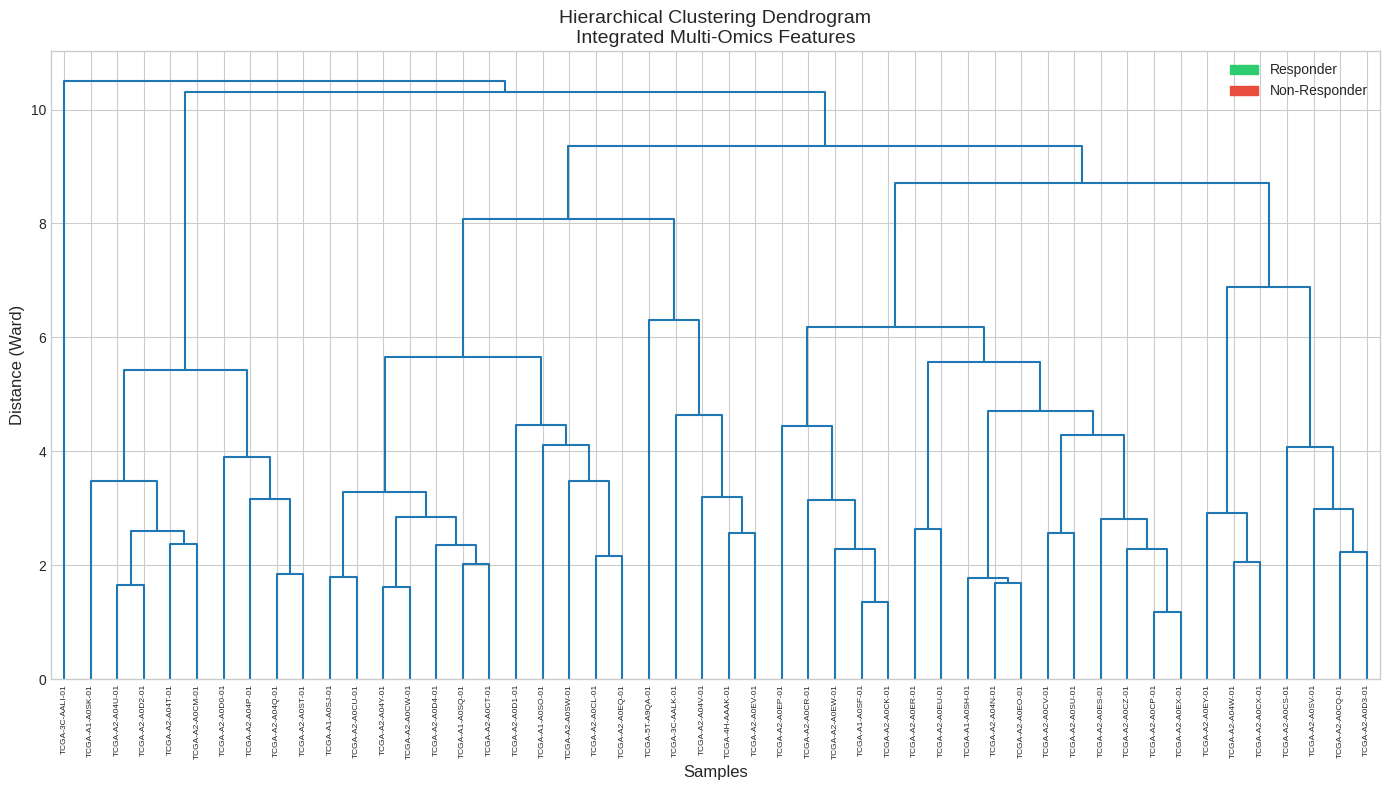

In [ ]:
def plot_dendrogram(X: pd.DataFrame, pheno: pd.Series, save_path: Path = None):
    """Create hierarchical clustering dendrogram."""

    # Perform hierarchical clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    linkage_matrix = linkage(X_scaled, method="ward")

    fig, ax = plt.subplots(figsize=(14, 8))

    # Color samples by phenotype
    colors = {"responder": "#2ecc71", "non_responder": "#e74c3c"}
    sample_colors = [colors[p] for p in pheno.values]

    dendro = dendrogram(
        linkage_matrix,
        labels=X.index.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        ax=ax,
        color_threshold=0,
    )

    ax.set_xlabel("Samples", fontsize=12)
    ax.set_ylabel("Distance (Ward)", fontsize=12)
    ax.set_title(
        "Hierarchical Clustering Dendrogram\nIntegrated Multi-Omics Features",
        fontsize=14,
    )

    # Add legend
    legend_patches = [
        mpatches.Patch(color="#2ecc71", label="Responder"),
        mpatches.Patch(color="#e74c3c", label="Non-Responder"),
    ]
    ax.legend(handles=legend_patches, loc="upper right")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_dendrogram(
    X_pca.iloc[:50],  # Subset for readability
    pheno_df["phenotype"].iloc[:50],
    save_path=CONFIG.export_dir / f"task4_dendrogram.{CONFIG.figure_format}",
)

## 6. Volcano Plot for Differential Expression

[OK] Saved: artifacts/task4_volcano.png


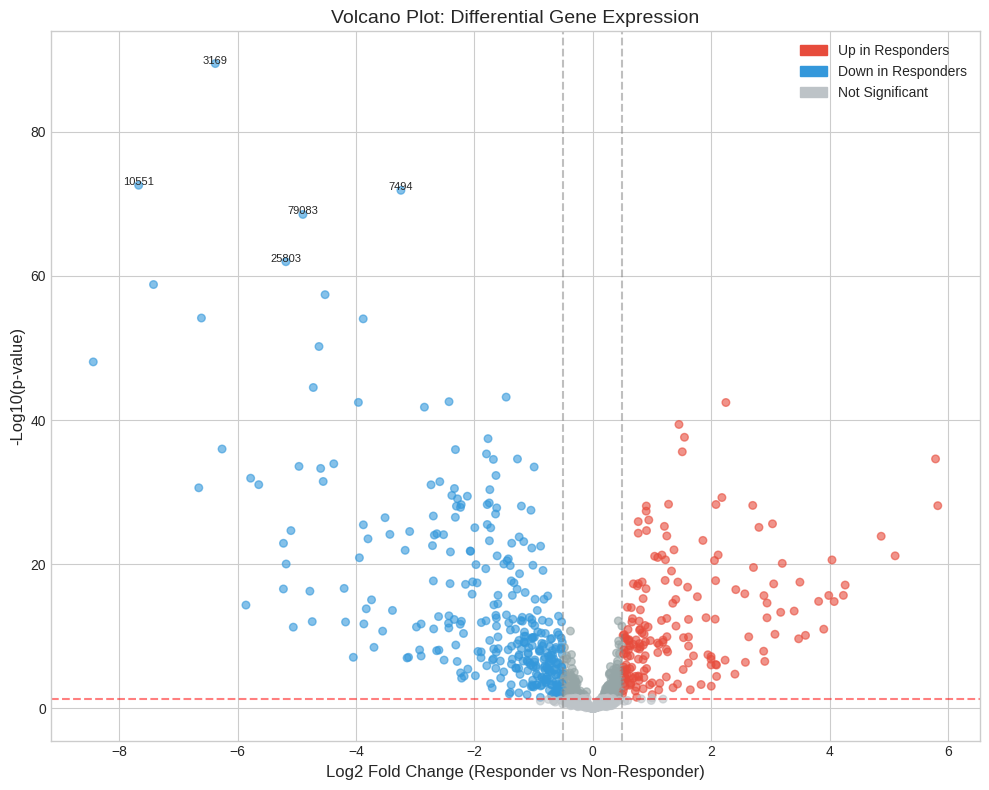

In [ ]:
def plot_volcano(de_results: pd.DataFrame, save_path: Path = None):
    """Create volcano plot for differential expression."""

    fig, ax = plt.subplots(figsize=(10, 8))

    # Calculate -log10(p-value)
    de_results = de_results.copy()
    de_results["-log10_pvalue"] = -np.log10(de_results["p_value"] + 1e-300)

    # Color by significance and fold change
    colors = []
    for _, row in de_results.iterrows():
        if row["p_adjusted"] < 0.05:
            if row["log2_fold_change"] > 0.5:
                colors.append("#e74c3c")  # Up in responders
            elif row["log2_fold_change"] < -0.5:
                colors.append("#3498db")  # Down in responders
            else:
                colors.append("#95a5a6")  # Significant but small FC
        else:
            colors.append("#bdc3c7")  # Not significant

    ax.scatter(
        de_results["log2_fold_change"],
        de_results["-log10_pvalue"],
        c=colors,
        alpha=0.6,
        s=30,
    )

    # Add significance lines
    ax.axhline(
        y=-np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="p=0.05"
    )
    ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(x=-0.5, color="gray", linestyle="--", alpha=0.5)

    # Label top genes
    top_genes = de_results.nsmallest(5, "p_value")
    for _, row in top_genes.iterrows():
        ax.annotate(
            row["gene"],
            (row["log2_fold_change"], row["-log10_pvalue"]),
            fontsize=8,
            ha="center",
        )

    ax.set_xlabel("Log2 Fold Change (Responder vs Non-Responder)", fontsize=12)
    ax.set_ylabel("-Log10(p-value)", fontsize=12)
    ax.set_title("Volcano Plot: Differential Gene Expression", fontsize=14)

    # Legend
    legend_elements = [
        mpatches.Patch(color="#e74c3c", label="Up in Responders"),
        mpatches.Patch(color="#3498db", label="Down in Responders"),
        mpatches.Patch(color="#bdc3c7", label="Not Significant"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_volcano(
    de_results, save_path=CONFIG.export_dir / f"task4_volcano.{CONFIG.figure_format}"
)

## 7. Model Comparison Charts

[OK] Saved: artifacts/task4_ml_comparison.png


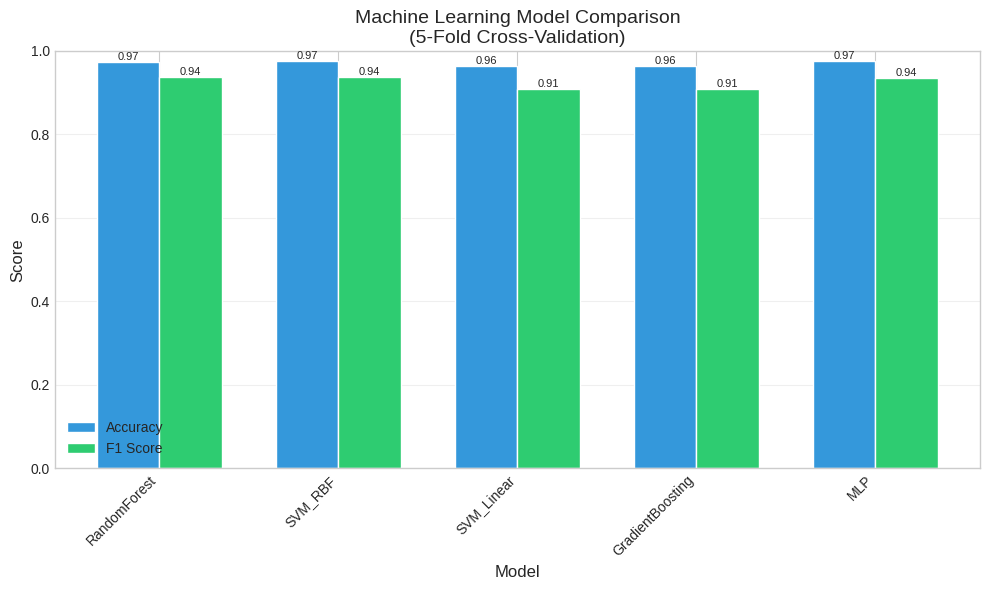

In [ ]:
def plot_ml_comparison(ml_results: pd.DataFrame, save_path: Path = None):
    """Create bar chart comparing ML model performance."""

    fig, ax = plt.subplots(figsize=(10, 6))

    # Parse accuracy values (format: "0.xxx ± 0.xxx")
    ml_results = ml_results.copy()

    models = ml_results["model"]
    x = np.arange(len(models))
    width = 0.35

    # Plot bars
    bars = ax.bar(
        x,
        ml_results["accuracy_mean"],
        width,
        label="Accuracy",
        color="#3498db",
        edgecolor="white",
    )

    bars2 = ax.bar(
        x + width,
        ml_results["f1_mean"],
        width,
        label="F1 Score",
        color="#2ecc71",
        edgecolor="white",
    )

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(
        "Machine Learning Model Comparison\n(5-Fold Cross-Validation)", fontsize=14
    )
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
        )

    for bar in bars2:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_ml_comparison(
    ml_results,
    save_path=CONFIG.export_dir / f"task4_ml_comparison.{CONFIG.figure_format}",
)

[OK] Saved: artifacts/task4_threshold_heatmap.png


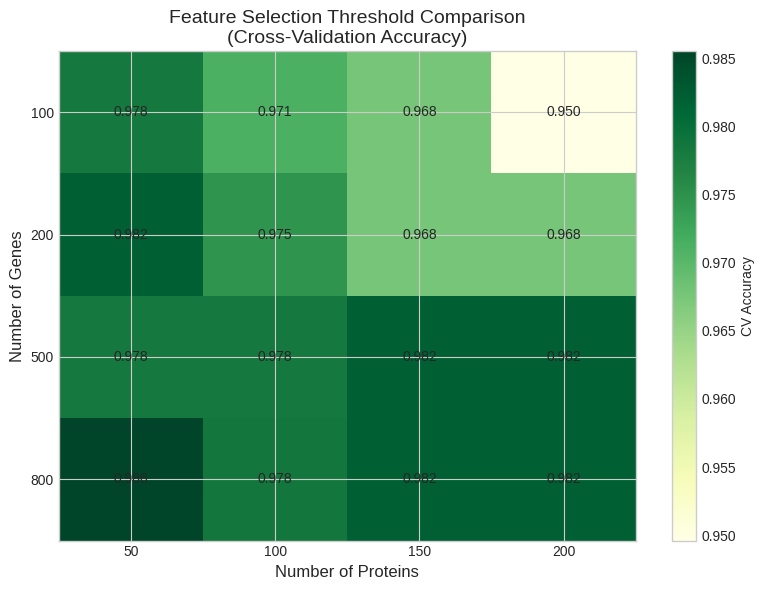

In [ ]:
def plot_feature_threshold_heatmap(
    threshold_results: pd.DataFrame, save_path: Path = None
):
    """Create heatmap of feature threshold experiment results."""

    fig, ax = plt.subplots(figsize=(8, 6))

    # Pivot data for heatmap
    pivot = threshold_results.pivot(
        index="n_genes", columns="n_proteins", values="cv_accuracy_mean"
    )

    im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("CV Accuracy", fontsize=10)

    # Set ticks
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticklabels(pivot.index)

    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            text = ax.text(
                j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=10
            )

    ax.set_xlabel("Number of Proteins", fontsize=12)
    ax.set_ylabel("Number of Genes", fontsize=12)
    ax.set_title(
        "Feature Selection Threshold Comparison\n(Cross-Validation Accuracy)",
        fontsize=14,
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_feature_threshold_heatmap(
    threshold_results,
    save_path=CONFIG.export_dir / f"task4_threshold_heatmap.{CONFIG.figure_format}",
)

## 8. Feature Importance Plot

02:35:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
02:35:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


[OK] Saved: artifacts/task4_feature_importance.png


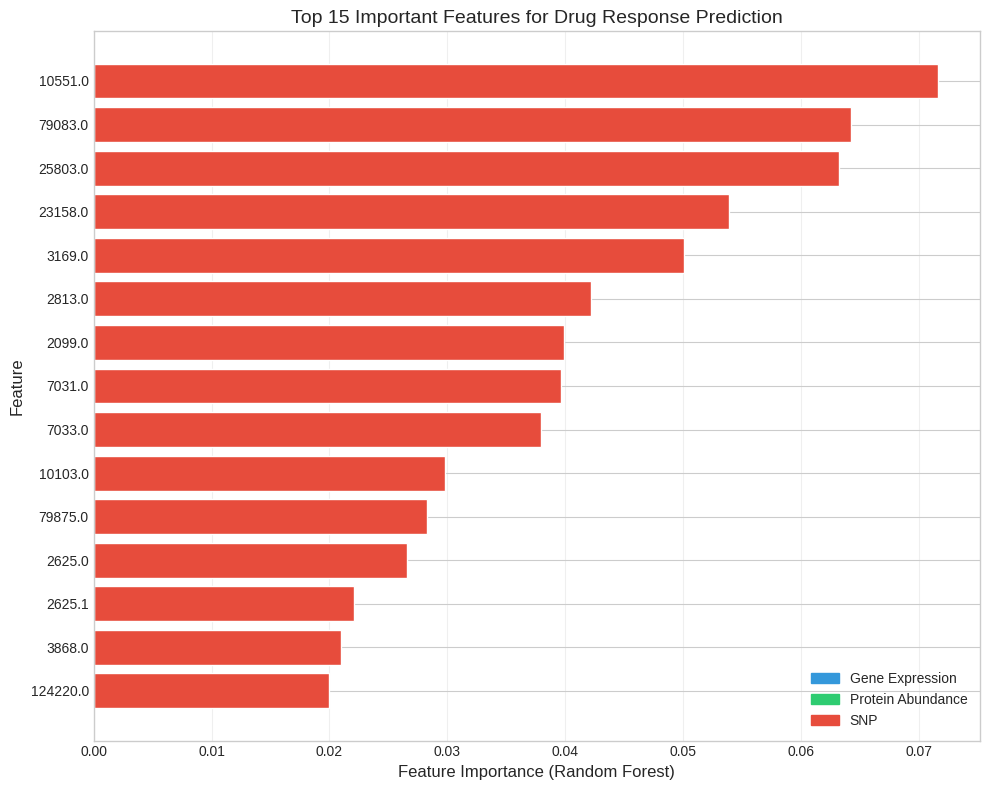

In [ ]:
def plot_feature_importance(
    rf_importance: pd.DataFrame, n_top: int = 15, save_path: Path = None
):
    """Create horizontal bar chart of feature importance."""

    fig, ax = plt.subplots(figsize=(10, 8))

    top_features = rf_importance.head(n_top).iloc[::-1]  # Reverse for horizontal bars

    # Color coding for different feature types
    colors = []
    for feat in top_features["feature"]:
        feat_str = str(feat)  # Convert to string to handle numeric/NaN feature names
        if feat_str.startswith("GENE") or feat_str in [
            "TP53",
            "BRCA1",
            "BRCA2",
            "EGFR",
            "KRAS",
            "MYC",
        ]:
            colors.append("#3498db")  # Blue for genes
        elif feat_str.startswith("PROT") or feat_str in ["P53", "HER2", "VEGFA"]:
            colors.append("#2ecc71")  # Green for proteins
        elif feat_str.startswith("expr_") or any(
            c.isalpha() for c in feat_str[:5] if feat_str
        ):
            colors.append("#3498db")  # Blue for expression genes (real data)
        elif feat_str.startswith("prot_"):
            colors.append("#2ecc71")  # Green for proteins (real data)
        else:
            colors.append("#e74c3c")  # Red for SNPs

    bars = ax.barh(
        top_features["feature"].astype(str),
        top_features["importance"],
        color=colors,
        edgecolor="white",
    )

    ax.set_xlabel("Feature Importance (Random Forest)", fontsize=12)
    ax.set_ylabel("Feature", fontsize=12)
    ax.set_title(
        f"Top {n_top} Important Features for Drug Response Prediction", fontsize=14
    )
    ax.grid(axis="x", alpha=0.3)

    # Legend
    legend_elements = [
        mpatches.Patch(color="#3498db", label="Gene Expression"),
        mpatches.Patch(color="#2ecc71", label="Protein Abundance"),
        mpatches.Patch(color="#e74c3c", label="SNP"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")

    plt.show()


plot_feature_importance(
    rf_importance,
    n_top=15,
    save_path=CONFIG.export_dir / f"task4_feature_importance.{CONFIG.figure_format}",
)

## 9. t-SNE and UMAP Visualization

In [ ]:
# Install UMAP if needed (using uv)
try:
    import umap
except ImportError:
    import subprocess

    subprocess.check_call(["uv", "pip", "install", "umap-learn", "-q"])
    import umap

from sklearn.manifold import TSNE


def run_tsne_umap(X: pd.DataFrame, perplexity: int = 30, seed: int = 42):
    """Run t-SNE and UMAP dimensionality reduction."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, X.shape[0] - 1),
        random_state=seed,
        init="pca",
        learning_rate="auto",
    )
    X_tsne = tsne.fit_transform(X_scaled)

    # UMAP
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=seed)
    X_umap = reducer.fit_transform(X_scaled)

    return X_tsne, X_umap


X_tsne, X_umap = run_tsne_umap(X_integrated, seed=42)
print(f"t-SNE shape: {X_tsne.shape}, UMAP shape: {X_umap.shape}")

t-SNE shape: (277, 2), UMAP shape: (277, 2)


[OK] Saved: artifacts/task4_dr_comparison.png


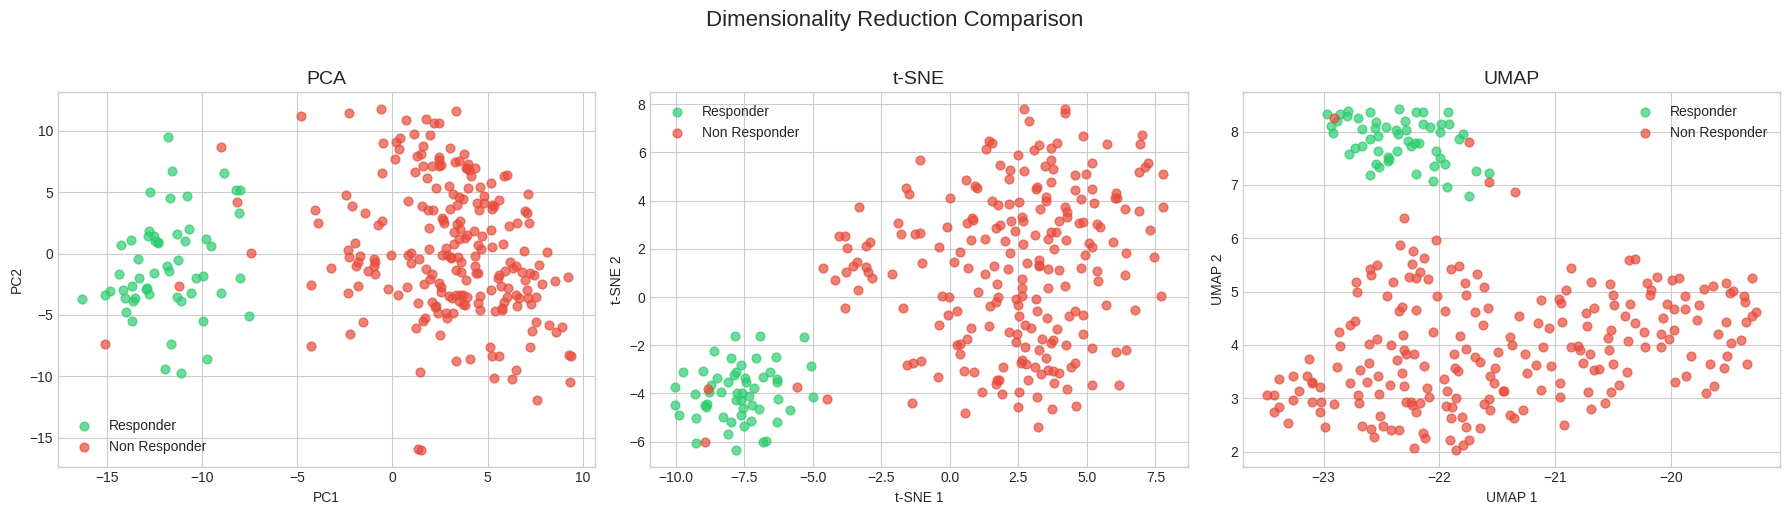

In [ ]:
def plot_dr_comparison(
    X_pca: pd.DataFrame,
    X_tsne: np.ndarray,
    X_umap: np.ndarray,
    phenotype: pd.Series,
    save_path: Path = None,
):
    """Compare PCA, t-SNE, and UMAP side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {"responder": "#2ecc71", "non_responder": "#e74c3c"}

    # PCA
    for pheno in ["responder", "non_responder"]:
        mask = phenotype == pheno
        samples = phenotype[mask].index
        axes[0].scatter(
            X_pca.loc[samples, "PC1"],
            X_pca.loc[samples, "PC2"],
            c=colors[pheno],
            label=pheno.replace("_", " ").title(),
            alpha=0.7,
            s=40,
        )
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].set_title("PCA", fontsize=14)
    axes[0].legend()

    # t-SNE
    for pheno in ["responder", "non_responder"]:
        mask = phenotype == pheno
        axes[1].scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=colors[pheno],
            label=pheno.replace("_", " ").title(),
            alpha=0.7,
            s=40,
        )
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    axes[1].set_title("t-SNE", fontsize=14)
    axes[1].legend()

    # UMAP
    for pheno in ["responder", "non_responder"]:
        mask = phenotype == pheno
        axes[2].scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=colors[pheno],
            label=pheno.replace("_", " ").title(),
            alpha=0.7,
            s=40,
        )
    axes[2].set_xlabel("UMAP 1")
    axes[2].set_ylabel("UMAP 2")
    axes[2].set_title("UMAP", fontsize=14)
    axes[2].legend()

    plt.suptitle("Dimensionality Reduction Comparison", fontsize=16, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")
    plt.show()


plot_dr_comparison(
    X_pca,
    X_tsne,
    X_umap,
    pheno_df["phenotype"],
    CONFIG.export_dir / "task4_dr_comparison.png",
)

## 10.Network-Based Integration

In [ ]:
# Load expression data for network analysis
expr_df = pd.read_csv(CONFIG.data_dir / "task1_expression_data.csv", index_col=0)


def build_correlation_network(expr_df: pd.DataFrame, threshold: float = 0.4):
    """Build gene-gene correlation network with hub identification."""
    # Select top 100 variable genes
    variances = expr_df.var(axis=1)
    top_genes = variances.nlargest(100).index
    expr_subset = expr_df.loc[top_genes]

    # Compute correlation matrix
    corr_matrix = expr_subset.T.corr()

    # Create edge list (lowered threshold to get more edges)
    edges = []
    for i, gene1 in enumerate(corr_matrix.index):
        for j, gene2 in enumerate(corr_matrix.columns):
            if i < j and abs(corr_matrix.loc[gene1, gene2]) > threshold:
                edges.append(
                    {
                        "source": gene1,
                        "target": gene2,
                        "correlation": corr_matrix.loc[gene1, gene2],
                        "weight": abs(corr_matrix.loc[gene1, gene2]),
                    }
                )

    edge_df = pd.DataFrame(edges)
    print(
        f"Network: {len(top_genes)} nodes, {len(edges)} edges (threshold={threshold})"
    )
    return corr_matrix, edge_df


# Use lower threshold (0.4) to capture more network connections
corr_matrix, edge_df = build_correlation_network(expr_df, threshold=0.4)
edge_df.head(10)

Network: 100 nodes, 654 edges (threshold=0.4)


,source,target,correlation,weight
0,4250,10647,0.949336,0.949336
1,4250,7031,0.460061,0.460061
2,4250,5304,0.425277,0.425277
3,4250,118430,0.470721,0.470721
4,4250,199974,0.434106,0.434106
5,4250,3158,0.418627,0.418627
6,4250,1048,0.465308,0.465308
7,4250,7033,0.459597,0.459597
8,4250,10551,0.441865,0.441865
9,4250,10720,0.441333,0.441333


In [ ]:
def identify_hub_genes(edge_df: pd.DataFrame, n_top: int = 10) -> pd.DataFrame:
    """Identify hub genes by degree centrality."""
    if len(edge_df) == 0:
        return pd.DataFrame(columns=["gene", "degree", "avg_correlation"])

    source_counts = edge_df["source"].value_counts()
    target_counts = edge_df["target"].value_counts()
    all_genes = set(edge_df["source"]) | set(edge_df["target"])

    hub_data = []
    for gene in all_genes:
        degree = source_counts.get(gene, 0) + target_counts.get(gene, 0)
        gene_edges = edge_df[(edge_df["source"] == gene) | (edge_df["target"] == gene)]
        avg_corr = gene_edges["correlation"].abs().mean()
        hub_data.append({"gene": gene, "degree": degree, "avg_correlation": avg_corr})

    return pd.DataFrame(hub_data).sort_values("degree", ascending=False).head(n_top)


hub_genes = identify_hub_genes(edge_df, n_top=10)
print("Top Hub Genes (by degree centrality):")
print(hub_genes.to_string(index=False))

Top Hub Genes (by degree centrality):
 gene  degree  avg_correlation
 3169      49         0.529375
 2099      43         0.536040
 3868      38         0.565573
 7033      36         0.529630
 8842      34         0.503304
 2568      33         0.588872
 3854      33         0.570976
 6422      33         0.571449
23650      32         0.585596
10551      32         0.550404


[OK] Saved: artifacts/task4_hub_correlation.png


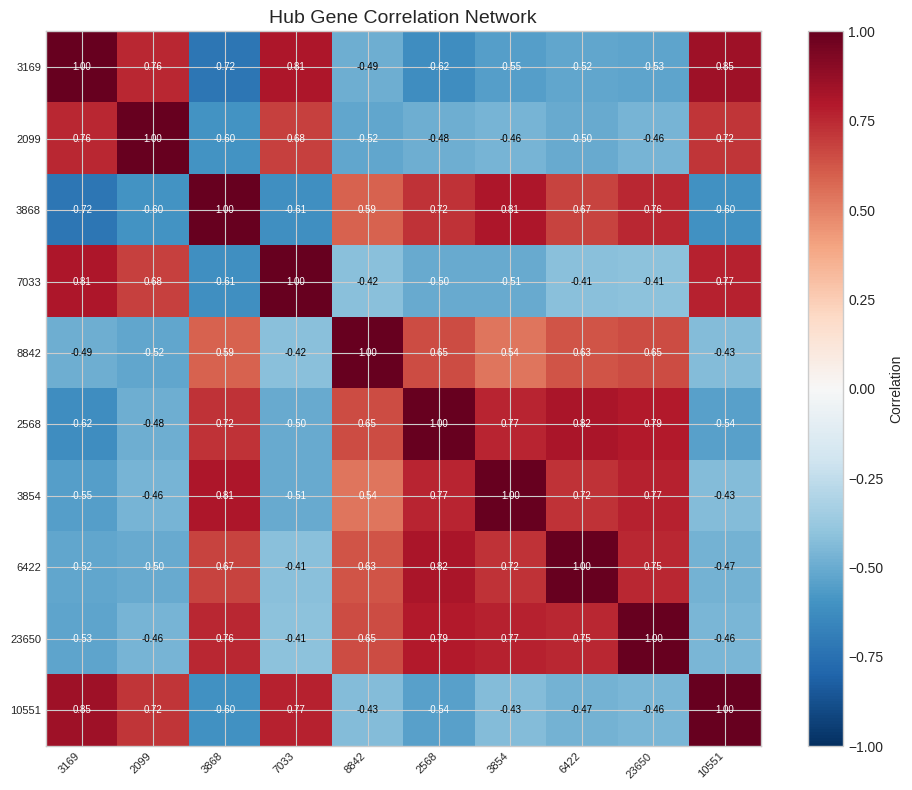

In [ ]:
def plot_hub_correlation_heatmap(
    corr_matrix: pd.DataFrame, hub_genes: pd.DataFrame, save_path: Path = None
):
    """Plot correlation heatmap for hub genes."""
    if len(hub_genes) == 0:
        print("No hub genes to plot")
        return

    hub_list = [g for g in hub_genes["gene"].tolist() if g in corr_matrix.index]
    if len(hub_list) < 2:
        print("Not enough hub genes")
        return

    hub_corr = corr_matrix.loc[hub_list, hub_list]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(hub_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Correlation")

    ax.set_xticks(np.arange(len(hub_corr.columns)))
    ax.set_yticks(np.arange(len(hub_corr.index)))
    ax.set_xticklabels(hub_corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(hub_corr.index, fontsize=8)

    for i in range(len(hub_corr.index)):
        for j in range(len(hub_corr.columns)):
            val = hub_corr.iloc[i, j]
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if abs(val) > 0.5 else "black",
            )

    ax.set_title("Hub Gene Correlation Network", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")
    plt.show()


plot_hub_correlation_heatmap(
    corr_matrix, hub_genes, CONFIG.export_dir / "task4_hub_correlation.png"
)

[OK] Saved: artifacts/task4_network_graph.png


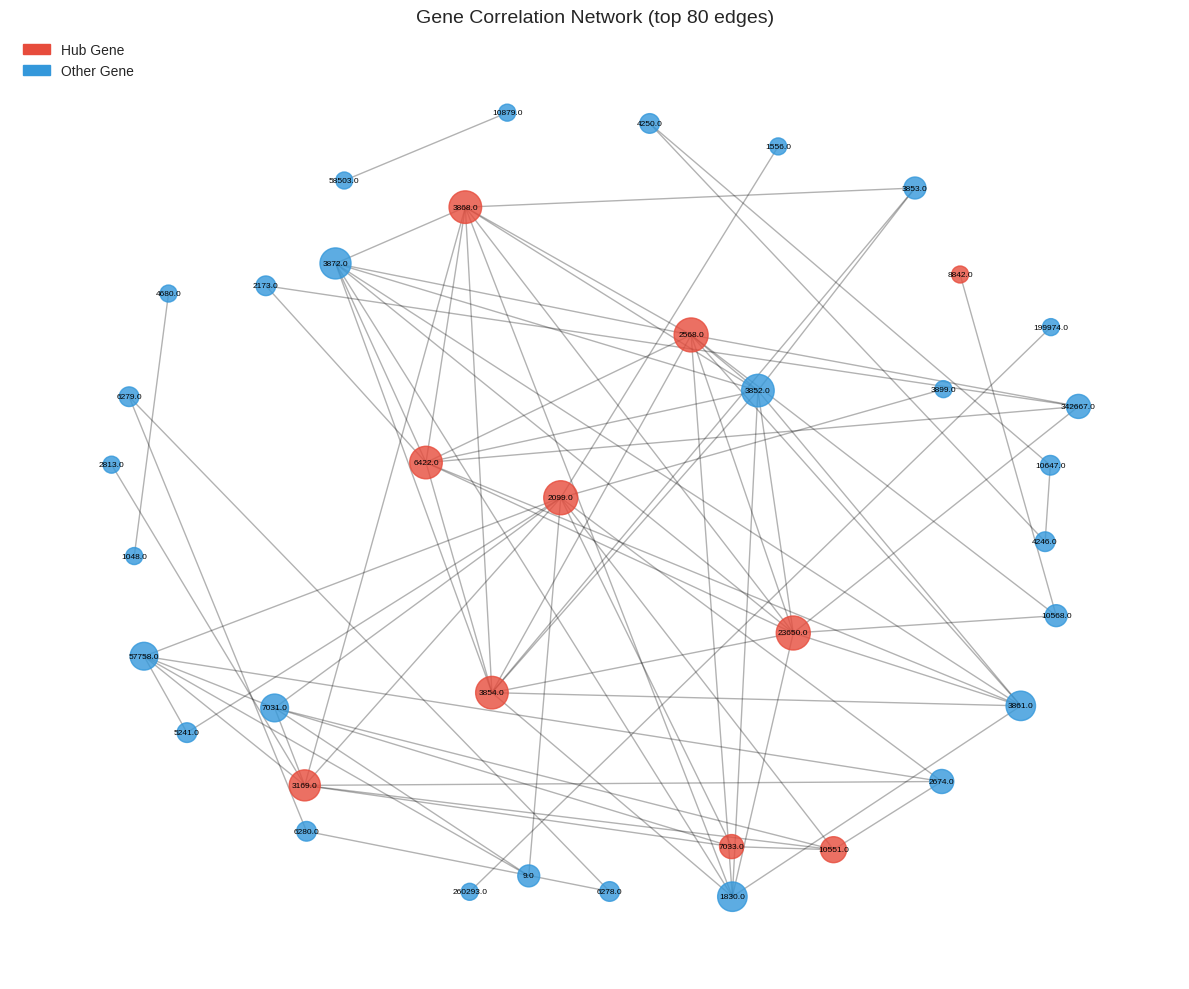

In [ ]:
try:
    import networkx as nx

    HAS_NX = True
except ImportError:
    import subprocess

    subprocess.check_call(["uv", "pip", "install", "networkx", "-q"])
    import networkx as nx

    HAS_NX = True


def plot_network_graph(
    edge_df: pd.DataFrame,
    hub_genes: pd.DataFrame,
    max_edges: int = 80,
    save_path: Path = None,
):
    """Plot network graph with hub genes highlighted."""
    if len(edge_df) == 0:
        print("No edges to plot")
        return

    fig, ax = plt.subplots(figsize=(12, 10))
    G = nx.Graph()

    edge_subset = edge_df.nlargest(max_edges, "weight")
    for _, row in edge_subset.iterrows():
        G.add_edge(row["source"], row["target"], weight=row["weight"])

    hub_set = set(hub_genes["gene"].tolist()) if len(hub_genes) > 0 else set()
    node_colors = ["#e74c3c" if n in hub_set else "#3498db" for n in G.nodes()]
    degrees = dict(G.degree())
    node_sizes = [100 + degrees[n] * 50 for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)

    legend_elements = [
        mpatches.Patch(color="#e74c3c", label="Hub Gene"),
        mpatches.Patch(color="#3498db", label="Other Gene"),
    ]
    ax.legend(handles=legend_elements, loc="upper left")
    ax.set_title(
        f"Gene Correlation Network (top {len(edge_subset)} edges)", fontsize=14
    )
    ax.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved: {save_path}")
    plt.show()


plot_network_graph(
    edge_df,
    hub_genes,
    max_edges=80,
    save_path=CONFIG.export_dir / "task4_network_graph.png",
)

In [ ]:
# Export extension results
tsne_df = pd.DataFrame(X_tsne, index=X_integrated.index, columns=["tSNE1", "tSNE2"])
tsne_df["phenotype"] = pheno_df["phenotype"].values
tsne_df.to_csv(CONFIG.export_dir / "task4_tsne_coordinates.csv")

umap_df = pd.DataFrame(X_umap, index=X_integrated.index, columns=["UMAP1", "UMAP2"])
umap_df["phenotype"] = pheno_df["phenotype"].values
umap_df.to_csv(CONFIG.export_dir / "task4_umap_coordinates.csv")

edge_df.to_csv(CONFIG.export_dir / "task4_network_edges.csv", index=False)
hub_genes.to_csv(CONFIG.export_dir / "task4_hub_genes.csv", index=False)

print("[OK] Extension data exported:")
print(f"  - task4_tsne_coordinates.csv")
print(f"  - task4_umap_coordinates.csv")
print(f"  - task4_network_edges.csv")
print(f"  - task4_hub_genes.csv")

[OK] Extension data exported:
  - task4_tsne_coordinates.csv
  - task4_umap_coordinates.csv
  - task4_network_edges.csv
  - task4_hub_genes.csv


## 9. Validate Outputs

In [ ]:
# Validate all figures were saved
EXPORT_DIR = CONFIG.export_dir

expected_files = [
    f"task4_pca_phenotype.{CONFIG.figure_format}",
    f"task4_pca_clusters.{CONFIG.figure_format}",
    f"task4_dendrogram.{CONFIG.figure_format}",
    f"task4_volcano.{CONFIG.figure_format}",
    f"task4_ml_comparison.{CONFIG.figure_format}",
    f"task4_threshold_heatmap.{CONFIG.figure_format}",
    f"task4_feature_importance.{CONFIG.figure_format}",
    # Extension files
    f"task4_dr_comparison.{CONFIG.figure_format}",
]

# Optional extension files (may not be created if no network edges)
optional_files = [
    f"task4_hub_correlation.{CONFIG.figure_format}",
    f"task4_network_graph.{CONFIG.figure_format}",
]

for fname in expected_files:
    fpath = EXPORT_DIR / fname
    assert fpath.exists(), f"Missing required file: {fname}"
    print(f"[OK] {fname}")

for fname in optional_files:
    fpath = EXPORT_DIR / fname
    if fpath.exists():
        print(f"[OK] {fname}")
    else:
        print(f"[SKIP] {fname} (no network edges met threshold)")

print("\n[OK] All visualization files validated!")

[OK] task4_pca_phenotype.png
[OK] task4_pca_clusters.png
[OK] task4_dendrogram.png
[OK] task4_volcano.png
[OK] task4_ml_comparison.png
[OK] task4_threshold_heatmap.png
[OK] task4_feature_importance.png
[OK] task4_dr_comparison.png
[OK] task4_hub_correlation.png
[OK] task4_network_graph.png

[OK] All visualization files validated!


In [ ]:
# Final summary
print("\n" + "=" * 60)
print("TASK 4 VISUALIZATION SUMMARY")
print("=" * 60)

print(f"\nGenerated Figures:")
for fname in expected_files:
    fpath = EXPORT_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    print(f"  - {fname} ({size_kb:.1f} KB)")

print(f"\nAll figures saved to: {EXPORT_DIR.resolve()}")
print("=" * 60)


TASK 4 VISUALIZATION SUMMARY

Generated Figures:
  - task4_pca_phenotype.png (110.0 KB)
  - task4_pca_clusters.png (257.5 KB)
  - task4_dendrogram.png (86.1 KB)
  - task4_volcano.png (216.3 KB)
  - task4_ml_comparison.png (66.4 KB)
  - task4_threshold_heatmap.png (79.6 KB)
  - task4_feature_importance.png (78.2 KB)
  - task4_dr_comparison.png (229.7 KB)

All figures saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/10_integrative/assignments/artifacts
